In [28]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
import pandas as pd
from pathlib import Path


%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns
import src.util_analysis as util_analysis

In [29]:
analysis_dir = Path(f"binaural_unit_activation_analysis/")
all_models = list(analysis_dir.glob("*v10*"))
models_to_run = []

for path in all_models:
    if not path.is_dir():
        continue
    if 'main' in path.stem and not ('latest' in path.stem or 'random' in path.stem):
        continue 
    if 'control' in path.stem:
        continue

    models_to_run.append(path)

def get_model_name(stem):
    if 'late_only' in stem:
        return 'Late-only'
    elif 'early_only' in stem:
        return 'Early-only'
    elif 'control' in stem:
        return 'Baseline CNN'
    elif 'arch' in stem:
        arch_n = stem.split('_')[-1]
        return f'Feature-gain alt v{arch_n}'
    elif 'rand' in stem:
        return 'Feature-gain random weights'
    elif "main" in stem:
        return 'Feature-gain main'

model_name_dict = {path.stem: get_model_name(path.stem) for path in models_to_run}


In [30]:
model_name_dict

{'word_task_early_only_v10': 'Early-only',
 'word_task_late_only_v10': 'Late-only',
 'word_task_v10_4MGB_ln_first_arch_1': 'Feature-gain alt v1',
 'word_task_v10_4MGB_ln_first_arch_10': 'Feature-gain alt v10',
 'word_task_v10_4MGB_ln_first_arch_12': 'Feature-gain alt v12',
 'word_task_v10_4MGB_ln_first_arch_2': 'Feature-gain alt v2',
 'word_task_v10_4MGB_ln_first_arch_4': 'Feature-gain alt v4',
 'word_task_v10_4MGB_ln_first_arch_6': 'Feature-gain alt v6',
 'word_task_v10_4MGB_ln_first_arch_7': 'Feature-gain alt v7',
 'word_task_v10_4MGB_ln_first_arch_8': 'Feature-gain alt v8',
 'word_task_v10_4MGB_ln_first_arch_9': 'Feature-gain alt v9',
 'word_task_v10_main_feature_gain_config_latest_ckpt': 'Feature-gain main',
 'word_task_v10_main_feature_gain_config_latest_ckpt_rand_weights': 'Feature-gain random weights'}

In [31]:
models_to_run

[PosixPath('binaural_unit_activation_analysis/word_task_early_only_v10'),
 PosixPath('binaural_unit_activation_analysis/word_task_late_only_v10'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_1'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_10'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_12'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_2'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_4'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_6'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_7'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_8'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_9'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckp

In [32]:
# corr_dfs = []
# cos_dfs = []

# for path in paths:
distractor_conditions = ['same_sex_talker', 'diff_sex_talker',]#  'natural_scene']

# just look at 0,0 co-located examples 
# wanted_rows = np.where(np.all(target_locs == [0,0], axis=1))[0]
dfs = []

for model_dir in models_to_run:
    if model_dir.stem == 'word_task_v10_main_feature_gain_config_latest_ckpt':
        print("On main model")
    h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_diotic.h5"
    try:
        with h5py.File(h5_fn, 'r') as acts:
            ## Get keys with corr in them 
            # all_act_keys = list(acts.keys())
            layer_names = set([l.split('_target')[0] for l in acts.keys() if 'target' in l and not  any([str_part in l for str_part in ['_f0', '_loc', '_word']])]) # set to remove duplicates 
            for layer in layer_names:
                for dist_cond in distractor_conditions:
                    data_dict = {}
                    if dist_cond == 'same_sex_talker':
                        fg_corr_key = f"{layer}_target_mixture_same_corr"
                        bg_corr_key = f"{layer}_same_sex_dist_mixture_same_corr"
                    elif dist_cond == 'diff_sex_talker':
                        fg_corr_key = f"{layer}_target_mixture_diff_corr"
                        bg_corr_key = f"{layer}_diff_sex_dist_mixture_diff_corr"
                    elif dist_cond == 'natural_scene':
                        fg_corr_key = f"{layer}_target_mixture_nat_scene_corr"
                        bg_corr_key = f"{layer}_nat_scene_dist_mixture_nat_scene_corr"   
                    if layer == 'cochleagram':
                        bg_corr_key = bg_corr_key.replace('sex_', '')      

                    data_dict['fg_corrs'] = acts[fg_corr_key][:,0]
                    data_dict['bg_corrs'] = acts[bg_corr_key][:,0]
                    N_examples = len(data_dict['fg_corrs'])

                    data_dict['layer'] = [layer] * N_examples
                    data_dict['distractor_condition'] = [dist_cond] * N_examples

                    df = pd.DataFrame(data_dict)
                    df['model_name'] = model_name_dict[h5_fn.parent.name]
                    dfs.append(df)
    except Exception as e:
        print(e)
        print(model_dir)
        continue


act_results  = pd.concat(dfs, ignore_index=True)
act_results['layer'] = act_results['layer'].str.replace('_block_', '')

act_results['log_corr_ratio'] = np.log(np.sqrt(act_results['fg_corrs']**2 / act_results['bg_corrs']**2))

act_corrs = pd.melt(act_results[[col for col in act_results.columns if 'cos' not in col]], id_vars =['layer', 'distractor_condition', 'model_name'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")


act_corrs['Stream'].replace('fg_corrs','corr(target$_i$, mixture$_i$)',inplace=True)
act_corrs['Stream'].replace('bg_corrs','corr(distractor$_i$, mixture$_i$)',inplace=True)

act_corrs['distractor_condition'].replace('same_sex_talker','Same sex',inplace=True)
act_corrs['distractor_condition'].replace('diff_sex_talker','Different sex',inplace=True)
act_corrs['distractor_condition'].replace('natural_scene','Natural scene',inplace=True)

# same as above but cos instead of corrs 

# act_corrs['layer'].replace('cochleagram','cochlea',inplace=True)



Unable to synchronously open file (bad object header version number)
binaural_unit_activation_analysis/word_task_early_only_v10
Unable to synchronously open file (bad object header version number)
binaural_unit_activation_analysis/word_task_late_only_v10
Unable to synchronously open file (bad object header version number)
binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_1
Unable to synchronously open file (bad object header version number)
binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_10
Unable to synchronously open file (bad object header version number)
binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_12
Unable to synchronously open file (bad object header version number)
binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_2
Unable to synchronously open file (bad object header version number)
binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_4
Unable to synchronously open file (bad object header 

ValueError: No objects to concatenate

In [37]:
import re
# Get layer order per model. Will have from [cochleagram, norm_coch_rep, ..., attnfc, relufc]
layer_order_dict = {}

def get_int(val):
    return int(re.search(r'\d+', val).group())

for model in act_results['model_name'].unique():
    layers = act_results.loc[act_results['model_name'] == model, 'layer'].unique()
    # sort by the number in the layer name
    layers_to_sort = [l for l in layers if not(any([str_part in l for str_part in ['fc', 'coch']]))]
    sorted_intermediate_layers = sorted(layers_to_sort, key=get_int)
    sorted_layers = ['cochleagram', 'norm_coch_rep'] + sorted_intermediate_layers
    if 'attnfc' in layers:
        sorted_layers.append('attnfc')
    sorted_layers.append('relufc')
    layer_order_dict[model] = sorted_layers


KeyError: 'Feature-gain main'

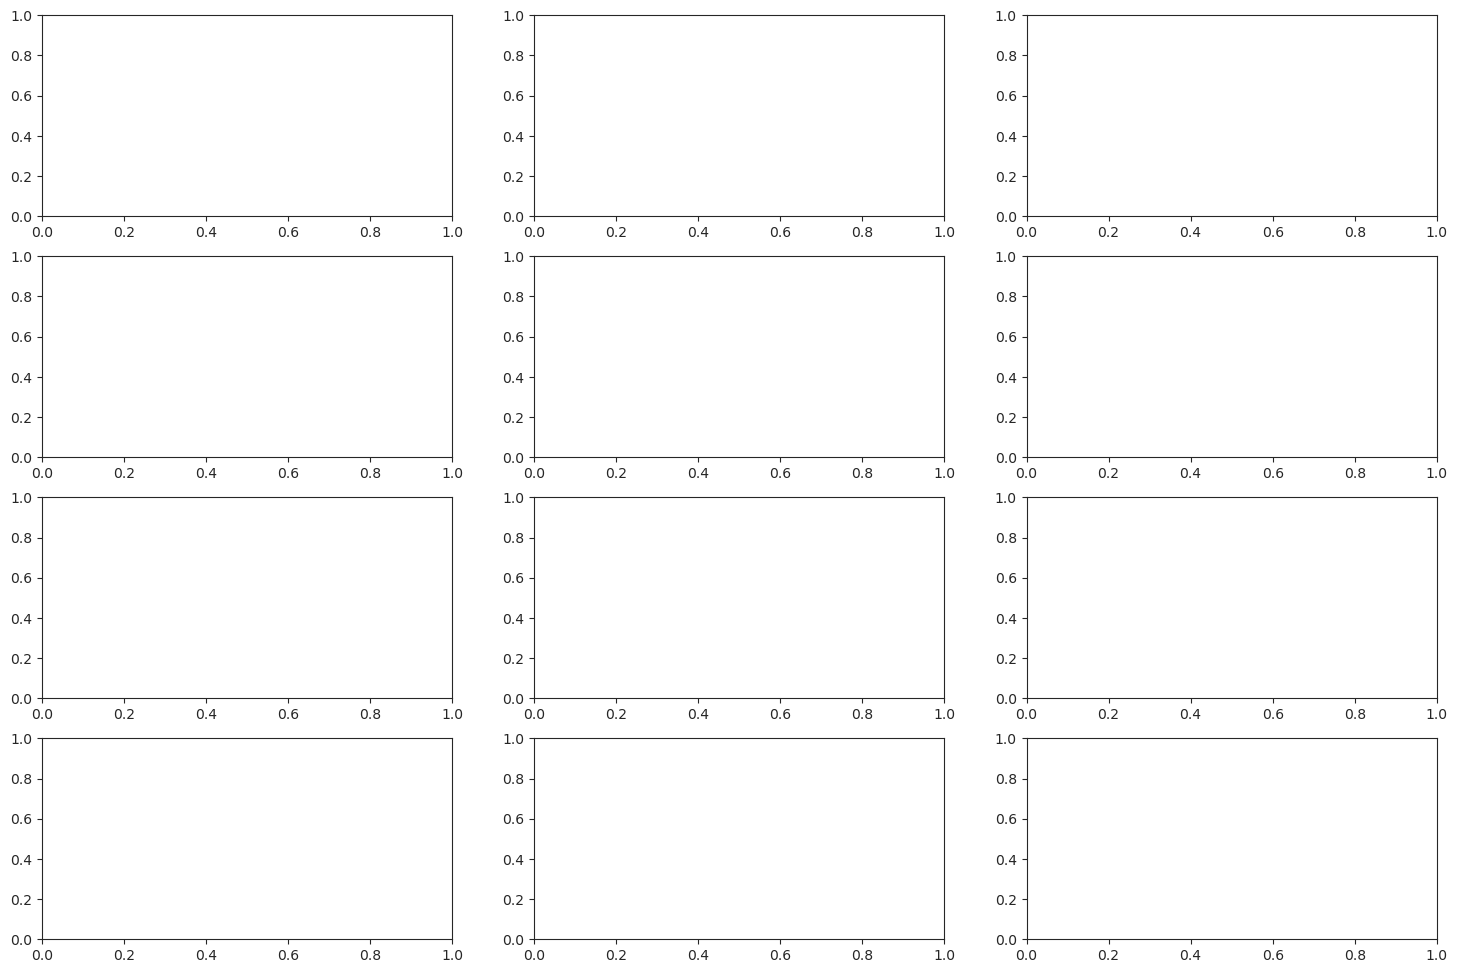

In [38]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)'] 
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-'}  

col_wrap = 3 
n_models = len(act_results['model_name'].unique())

n_cols = 3 
n_rows = int(np.ceil(n_models / n_cols))
panel_height = 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols* panel_height * 2, n_rows*panel_height), sharex=False, sharey=False)
axs = axs.flatten()

model_order = ['Feature-gain main', 'Early-only','Late-only' ]
# nat sort the other archs 
also_sort = [m for m in act_results['model_name'].unique() if m not in model_order]
model_order += sorted(also_sort, key=lambda x: int(re.search(r'\d+', x).group()))

for i, model in enumerate(model_order):
    to_plot = act_corrs[act_corrs['model_name'] == model].set_index('layer')
    to_plot = to_plot.loc[layer_order_dict[model]].reset_index()

    g = sns.lineplot(data=to_plot, x='layer', 
                     y="Pearson's r", hue='Stream', ax=axs[i],
                     palette=palette_dict,  hue_order=hue_order,
                     errorbar=('ci', 95)
                    )
    
    fontsize=10
    tick_fontsize = 8

    axs[i].set_xlabel("Network Layer", size=fontsize)
    axs[i].set_ylabel("Pearson's r", size=fontsize)
    axs[i].set_title(model, size=fontsize, y=1.05)
    # p.axes[0,0].xaxis.labelpad = -0.25
    # set y limit to 0,1
    axs[i].set(ylim=(0,1))
    # axs[i] move x axis label up 

    # p.set_
    axs[i].set_xticks(range(len(layer_order_dict[model])))
    axs[i].set_xticklabels(labels=layer_order_dict[model], rotation=90, size=tick_fontsize, 
                           ha='right', va='center_baseline',  rotation_mode='anchor')
    
plt.tight_layout()

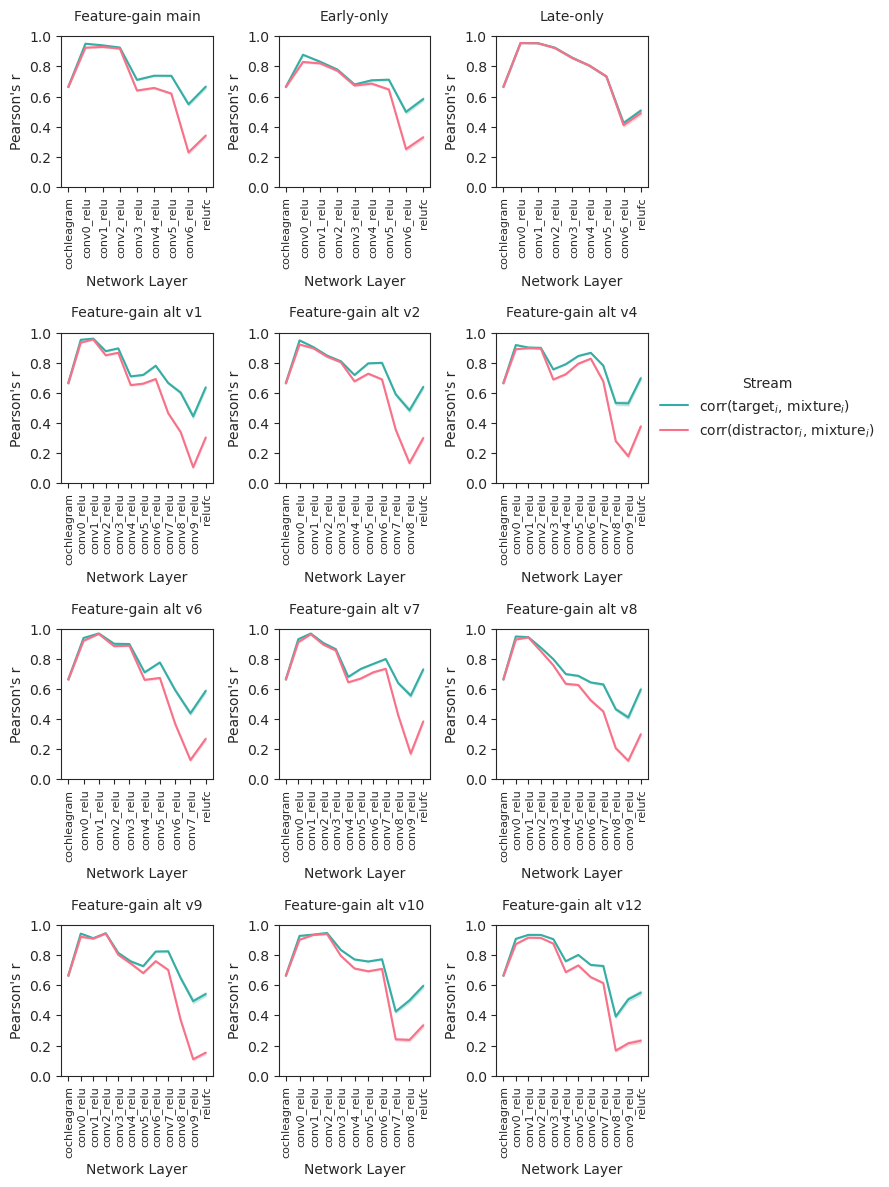

In [ ]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)'] 
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-'}  
 
col_wrap = 3 
n_models = len(act_results['model_name'].unique())

n_cols = 3 
n_rows = int(np.ceil(n_models / n_cols))
panel_height = 3
fontsize=10
tick_fontsize = 8


fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*panel_height, n_rows*panel_height), sharex=False, sharey=False)
axs = axs.flatten()


model_order = ['Feature-gain main', 'Early-only','Late-only' ]
# nat sort the other archs 
also_sort = [m for m in act_results['model_name'].unique() if m not in model_order]
model_order += sorted(also_sort, key=lambda x: int(re.search(r'\d+', x).group()))

for i, model in enumerate(model_order):
    to_plot = act_corrs[act_corrs['model_name'] == model].set_index('layer')
    layers = [l for l in layer_order_dict[model] if 'cochlea' in l or 'relu' in l]
    to_plot = to_plot.loc[layers].reset_index()

    g = sns.lineplot(data=to_plot, x='layer', 
                     y="Pearson's r", hue='Stream', ax=axs[i],
                     palette=palette_dict,  hue_order=hue_order,
                     errorbar=('ci', 95)
                    )

    axs[i].set_xlabel("Network Layer", size=fontsize)
    axs[i].set_ylabel("Pearson's r", size=fontsize)
    axs[i].set_title(model, size=fontsize, y=1.05)
    # p.axes[0,0].xaxis.labelpad = -0.25
    # set y limit to 0,1
    axs[i].set(ylim=(0,1))

    if i != 5:
        axs[i].legend().remove()

    axs[i].set_xticks(range(len(layers)))
    axs[i].set_xticklabels(labels=layers, rotation=90, size=tick_fontsize, 
                           ha='right', va='center_baseline',  rotation_mode='anchor')

axs[5].legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Stream', frameon=False, title_fontsize=fontsize)
    
plt.tight_layout()

### Make above plot, skipping all dead units 

In [14]:
dead_unit_corrs = pd.concat([pd.read_pickle(pkl) for pkl in analysis_dir.glob("*/*skip_dead_units.*pkl")])

speech_dist_corrs = dead_unit_corrs[dead_unit_corrs.distractor_condition != "Natural scene"].copy().reset_index(drop=True) 
speech_dist_corrs = speech_dist_corrs[~speech_dist_corrs.model_name.isin(["Baseline CNN", 'Feature-gain v10 '])]



In [15]:
main_model_dead_unit_filt = speech_dist_corrs[speech_dist_corrs.model_name == 'Feature-gain main']
main_model_all_units = act_corrs[act_corrs.model_name == 'Feature-gain main']

In [16]:
main_model_dead_unit_filt.sort_values('layer', inplace=True)
main_model_all_units.sort_values('layer', inplace=True)

/tmp/ipykernel_1249131/3534133746.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_model_dead_unit_filt.sort_values('layer', inplace=True)
/tmp/ipykernel_1249131/3534133746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_model_all_units.sort_values('layer', inplace=True)


In [17]:
import re
# Get layer order per model. Will have from [cochleagram, norm_coch_rep, ..., attnfc, relufc]
layer_order_dict = {}

def get_int(val):
    return int(re.search(r'\d+', val).group())

for model in speech_dist_corrs['model_name'].unique():
    layers = speech_dist_corrs.loc[speech_dist_corrs['model_name'] == model, 'layer'].unique()
    # sort by the number in the layer name
    layers_to_sort = [l for l in layers if not(any([str_part in l for str_part in ['fc', 'coch']]))]
    sorted_intermediate_layers = sorted(layers_to_sort, key=get_int)
    sorted_layers = ['cochleagram', 'norm_coch_rep'] + sorted_intermediate_layers
    if 'attnfc' in layers:
        sorted_layers.append('attnfc')
    sorted_layers.append('relufc')
    layer_order_dict[model] = sorted_layers


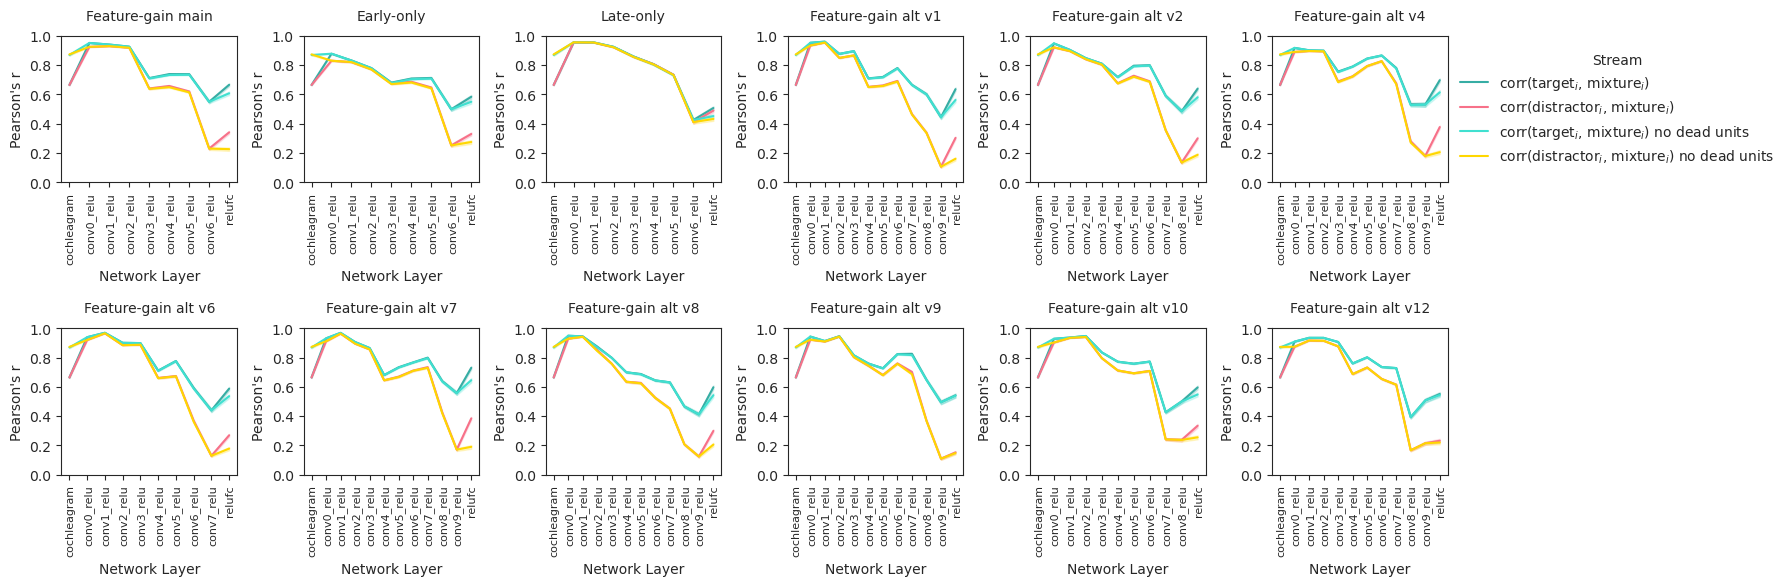

In [18]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)',
               'corr(target$_i$, mixture$_i$) no dead units', 'corr(distractor$_i$, mixture$_i$) no dead units'] 

# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],
                'corr(target$_i$, mixture$_i$) no dead units': 'turquoise',
                'corr(distractor$_i$, mixture$_i$) no dead units': 'gold',
                }
# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-'}  
 
col_wrap = 3 
n_models = len(speech_dist_corrs['model_name'].unique())

n_cols = 6
n_rows = int(np.ceil(n_models / n_cols))
panel_height = 3
fontsize=10
tick_fontsize = 8


fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*panel_height, n_rows*panel_height), sharex=False, sharey=False)
axs = axs.flatten()


model_order = ['Feature-gain main', 'Early-only','Late-only' ]
# nat sort the other archs 
also_sort = [m for m in speech_dist_corrs['model_name'].unique() if m not in model_order]
model_order += sorted(also_sort, key=lambda x: int(re.search(r'\d+', x).group()))

for i, model in enumerate(model_order):
    to_plot = speech_dist_corrs[speech_dist_corrs['model_name'] == model].set_index('layer')
    layers = [l for l in layer_order_dict[model] if 'cochlea' in l or 'relu' in l]
    to_plot = to_plot.loc[layers].reset_index()

    g = sns.lineplot(data=to_plot, x='layer', 
                     y="Pearson's r", hue='Stream', ax=axs[i],
                     palette=palette_dict,  hue_order=hue_order,
                     errorbar=('ci', 95)
                    )

    axs[i].set_xlabel("Network Layer", size=fontsize)
    axs[i].set_ylabel("Pearson's r", size=fontsize)
    axs[i].set_title(model, size=fontsize, y=1.05)
    # p.axes[0,0].xaxis.labelpad = -0.25
    # set y limit to 0,1
    axs[i].set(ylim=(0,1))

    if i != 5:
        axs[i].legend().remove()

    axs[i].set_xticks(range(len(layers)))
    axs[i].set_xticklabels(labels=layers, rotation=90, size=tick_fontsize, 
                           ha='right', va='center_baseline',  rotation_mode='anchor')

axs[5].legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Stream', frameon=False, title_fontsize=fontsize)
    
plt.tight_layout()

/tmp/ipykernel_1243937/1457861937.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  for_plot['Stream'] = for_plot['Stream'].str.replace(' no dead units', '')


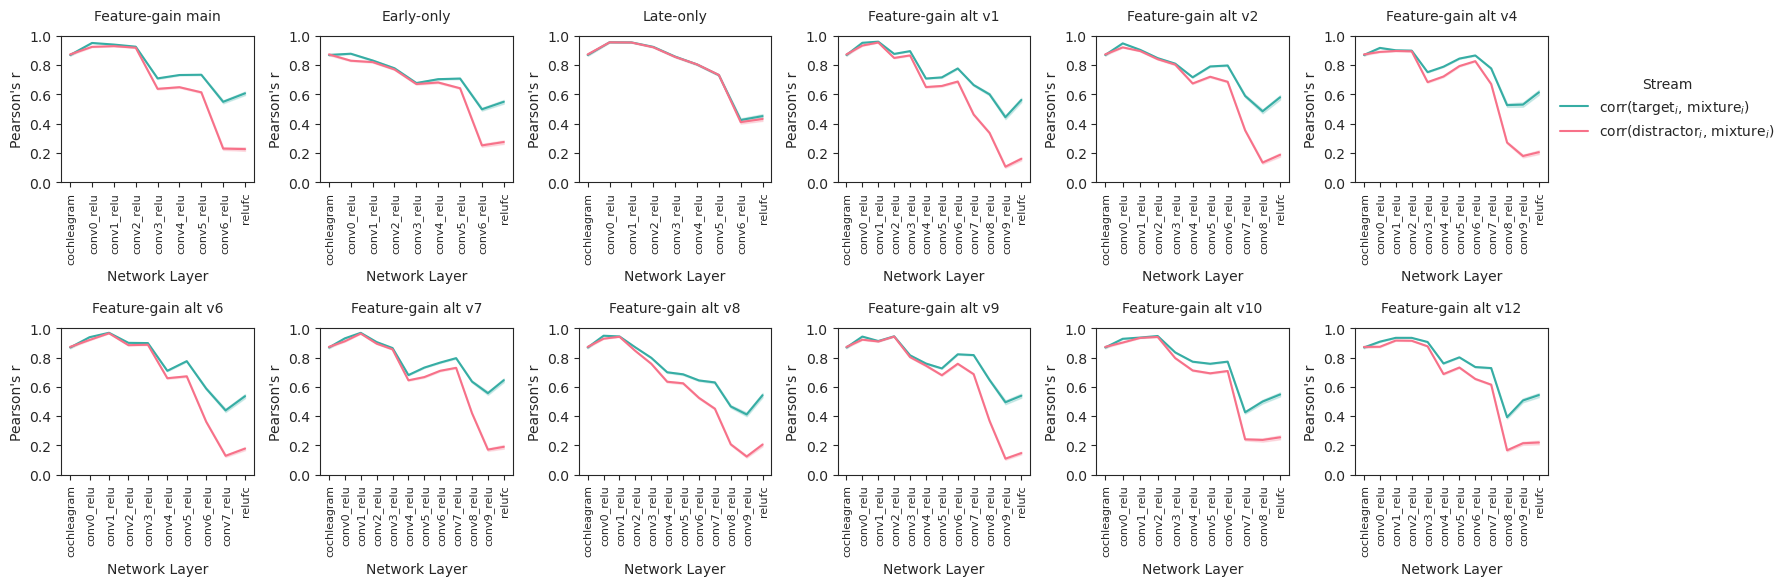

In [ ]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())

for_plot = speech_dist_corrs.copy()
for_plot = speech_dist_corrs[speech_dist_corrs.Stream.str.contains('no dead units')]

# remove no dead units from stream
for_plot['Stream'] = for_plot['Stream'].str.replace(' no dead units', '')


hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)',]
            #    'corr(target$_i$, mixture$_i$) no dead units', 'corr(distractor$_i$, mixture$_i$) no dead units'] 

# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],
                'corr(target$_i$, mixture$_i$) no dead units': 'turquoise',
                'corr(distractor$_i$, mixture$_i$) no dead units': 'gold',
                }
# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-'}  
 
n_models = len(for_plot['model_name'].unique())

n_cols = 6
n_rows = int(np.ceil(n_models / n_cols))
panel_height = 3
fontsize=10
tick_fontsize = 8


fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*panel_height, n_rows*panel_height), sharex=False, sharey=False)
axs = axs.flatten()


model_order = ['Feature-gain main', 'Early-only','Late-only' ]
# nat sort the other archs 
also_sort = [m for m in for_plot['model_name'].unique() if m not in model_order]
model_order += sorted(also_sort, key=lambda x: int(re.search(r'\d+', x).group()))

for i, model in enumerate(model_order):
    to_plot = for_plot[for_plot['model_name'] == model].set_index('layer')
    layers = [l for l in layer_order_dict[model] if 'cochlea' in l or 'relu' in l]
    to_plot = to_plot.loc[layers].reset_index()

    g = sns.lineplot(data=to_plot, x='layer', 
                     y="Pearson's r", hue='Stream', ax=axs[i],
                     palette=palette_dict,  hue_order=hue_order,
                     errorbar=('ci', 95)
                    )

    axs[i].set_xlabel("Network Layer", size=fontsize)
    axs[i].set_ylabel("Pearson's r", size=fontsize)
    axs[i].set_title(model, size=fontsize, y=1.05)
    # p.axes[0,0].xaxis.labelpad = -0.25
    # set y limit to 0,1
    axs[i].set(ylim=(0,1))

    if i != 5:
        axs[i].legend().remove()

    axs[i].set_xticks(range(len(layers)))
    axs[i].set_xticklabels(labels=layers, rotation=90, size=tick_fontsize, 
                           ha='right', va='center_baseline',  rotation_mode='anchor')

axs[5].legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Stream', frameon=False, title_fontsize=fontsize)
    
plt.tight_layout()